In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [2]:
df = pd.read_csv('./data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**Preparing X and Y variable**

In [4]:
X = df.drop(columns=['math_score'])
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [5]:
y = df['math_score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [11]:
# Identify numerical and categorical columns
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print(f"Number of numerical features: {len(num_features)}")
print(num_features)

print(f"\nNumber of categorical features: {len(cat_features)}")
print(cat_features)

Number of numerical features: 2
['reading_score', 'writing_score']

Number of categorical features: 5
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
oh_transformer = OneHotEncoder(handle_unknown='ignore')

processor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', oh_transformer, cat_features)
    ]
)

In [13]:
X = processor.fit_transform(X)

In [14]:
X.shape

(1000, 19)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

In [16]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "Support Vector Regressor": SVR(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate the model
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(f"Model: {list(models.keys())[i]}")
    model_list.append(list(models.keys())[i])
    
    print('Model performance on Training set:')
    print(f"- Root Mean Squared Error: {model_train_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_train_mae:.4f}")
    print(f"- R2 Score: {model_train_r2:.4f}")
    print('----------------------------------')
    print('Model performance on Test set:')
    print(f"- Root Mean Squared Error: {model_test_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_test_mae:.4f}")
    print(f"- R2 Score: {model_test_r2:.4f}")

    r2_list.append(model_test_r2)
    print('=' * 30)
    print('\n')



Model: Linear Regression
Model performance on Training set:
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance on Test set:
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Model: Ridge Regression
Model performance on Training set:
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance on Test set:
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


Model: Lasso Regression
Model performance on Training set:
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance on Test set:
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Model: K-Nearest Neighbors
Model performance on Training set:
- Root Mean Squared Error: 5.7128
- Mean Absolute Error: 4

### Result

In [28]:
results_df = pd.DataFrame({
    'Model Name': model_list,
    'R2 Score': r2_list
}).sort_values(by=["R2 Score"], ascending=False)

results_df

,Model Name,R2 Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
9,CatBoost,0.851632
5,Random Forest,0.849625
6,AdaBoost,0.843473
2,Lasso Regression,0.825320
8,XGBoost,0.821221
3,K-Nearest Neighbors,0.783770
4,Decision Tree,0.735245
7,Support Vector Regressor,0.728600


Linear Regression

In [30]:
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

score = r2_score(y_test, y_pred)*100
print(f"R2 Score for Linear Regression: {score:.4f}%")

R2 Score for Linear Regression: 88.0433%


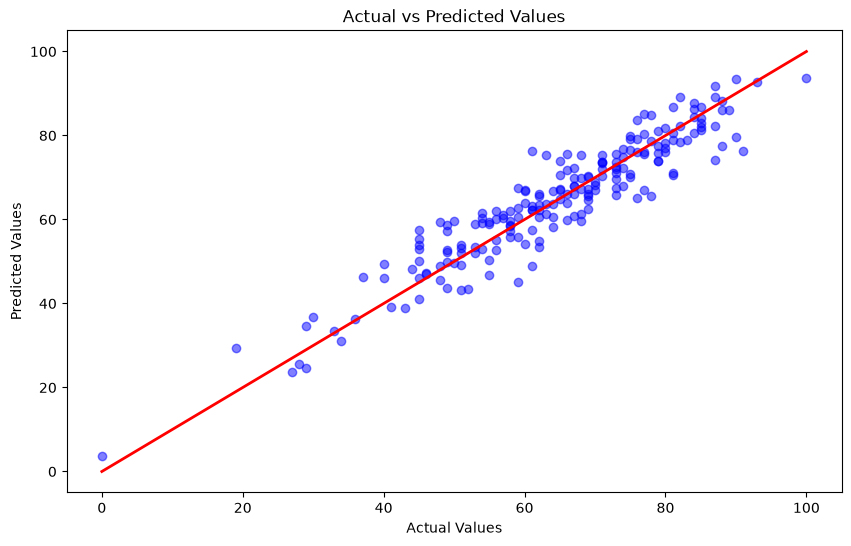

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.show()

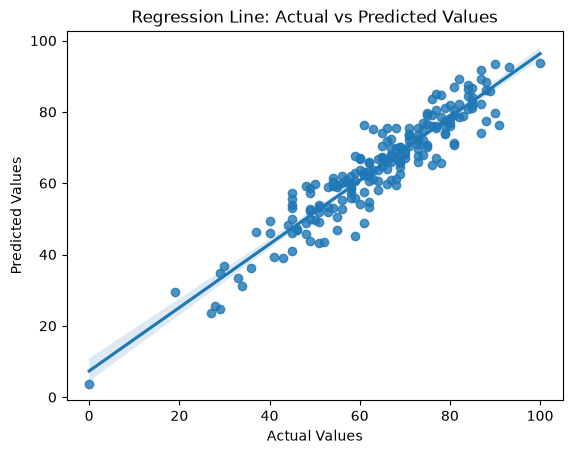

In [35]:
plt.Figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, ci=95)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Regression Line: Actual vs Predicted Values')
plt.show()